<a href="https://colab.research.google.com/github/sAI-2025/Intelligent-Customer-Signal-Detector/blob/main/Final_churn_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Churn Score Regression (0–100)



# Run

#### Train

In [36]:
# ============================================================
# CELL 1 — Load, Preprocess, Train (Decision Tree Regressor)
# Deliberately overfit: trained on 100% of the data, no
# train/test split, no held-out evaluation set.
# Target: churn_score_1 (0–100 regression)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

from google.colab import drive
drive.mount('/content/drive')

RAW_PATH = '/content/drive/MyDrive/FirstSource/Telco_customer_final_sample.csv'
TARGET_COL = 'churn_score_1'

DROP_COLS = [
    'avg_monthly_long_distance_charges',
    'churn',
    'churn_category',
    'churn_rate',
    'churn_reason',
    'city',
    'close_issue_count',
    'cltv',
    'count',
    'country',
    'customer_id',
    'customer_status',
    'device_protection',
    'lat_long',
    'latitude',
    'longitude',
    'online_backup',
    'online_security',
    'open_issue_count',
    'premium_tech_support',
    'referred_a_friend',
    'resolution_status_open_closed',
    'service_count',
    'state',
    'support_interaction_count',
    'tech_support',
    'total_long_distance_charges',
    'under_30',
    'zip_code',
    'total_charges',
    'total_revenue',
]

SATISFACTION_MAP = {'Low': 1, 'Medium': 2, 'High': 3}


def preprocess(df_raw: pd.DataFrame, is_training: bool = True) -> pd.DataFrame:
    """
    Single source-of-truth preprocessing function.
    Used identically for training (Cell 1) and inference (Cell 3).

    is_training=True  -> expects TARGET_COL to be present, keeps it in output.
    is_training=False -> target is optional; if absent, no target column is
                          added to the output.
    """
    df = df_raw.copy()

    # total_charges median-fill BEFORE it gets dropped below (kept for parity
    # with original script; the column itself is dropped from the feature set)
    if 'total_charges' in df.columns:
        df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
        df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())

    # 1. gender -> ismale
    if 'gender' in df.columns:
        df['ismale'] = (df['gender'].astype(str).str.strip() == 'Male').astype(int)
        df.drop(columns=['gender'], inplace=True)

    # 2. partner -> ispartner (engineered then dropped later per DROP_COLS parity)
    if 'partner' in df.columns:
        df['ispartner'] = (df['partner'] == 'Yes').astype(int)
        df.drop(columns=['partner'], inplace=True)

    # 3. dependents -> isdependents
    if 'dependents' in df.columns:
        df['isdependents'] = (df['dependents'] == 'Yes').astype(int)
        df.drop(columns=['dependents'], inplace=True)

    # 4. phone_service -> isphone_service
    if 'phone_service' in df.columns:
        df['isphone_service'] = (df['phone_service'] == 'Yes').astype(int)
        df.drop(columns=['phone_service'], inplace=True)

    # 5. multiple_lines -> ismultiple_lines
    if 'multiple_lines' in df.columns:
        df['multiple_lines'] = df['multiple_lines'].replace('No phone service', 'No')
        df['ismultiple_lines'] = (df['multiple_lines'] == 'Yes').astype(int)
        df.drop(columns=['multiple_lines'], inplace=True)

    # 6. internet_service -> isFiberOpticInternetService, DSLInternetService
    if 'internet_service' in df.columns:
        df['isFiberOpticInternetService'] = (df['internet_service'] == 'Fiber optic').astype(int)
        df['DSLInternetService'] = (df['internet_service'] == 'DSL').astype(int)
        df.drop(columns=['internet_service'], inplace=True)

    # 7. streaming_tv -> isstreaming_tv
    if 'streaming_tv' in df.columns:
        df['streaming_tv'] = df['streaming_tv'].replace('No internet service', 'No')
        df['isstreaming_tv'] = (df['streaming_tv'] == 'Yes').astype(int)
        df.drop(columns=['streaming_tv'], inplace=True)

    # 8. streaming_movies -> isstreaming_movies (engineered then dropped later)
    if 'streaming_movies' in df.columns:
        df['streaming_movies'] = df['streaming_movies'].replace('No internet service', 'No')
        df['isstreaming_movies'] = (df['streaming_movies'] == 'Yes').astype(int)
        df.drop(columns=['streaming_movies'], inplace=True)

    # 9. contract_type -> 3 one-hot columns
    if 'contract_type' in df.columns:
        df['iscontract_typeMonth-to-month'] = (df['contract_type'] == 'Month-to-month').astype(int)
        df['iscontract_typeTwo year'] = (df['contract_type'] == 'Two year').astype(int)
        df['iscontract_typeOne year'] = (df['contract_type'] == 'One year').astype(int)
        df.drop(columns=['contract_type'], inplace=True)

    # 10. paperless_billing -> ispaperless_billing
    if 'paperless_billing' in df.columns:
        df['ispaperless_billing'] = (df['paperless_billing'] == 'Yes').astype(int)
        df.drop(columns=['paperless_billing'], inplace=True)

    # 11. payment_method -> 4 one-hot columns
    if 'payment_method' in df.columns:
        df['ispayment_methodElectronic check'] = (df['payment_method'] == 'Electronic check').astype(int)
        df['ispayment_methodMailed check'] = (df['payment_method'] == 'Mailed check').astype(int)
        df['ispayment_methodBank transfer'] = (df['payment_method'] == 'Bank transfer (automatic)').astype(int)
        df['ispayment_methodCredit card'] = (df['payment_method'] == 'Credit card (automatic)').astype(int)
        df.drop(columns=['payment_method'], inplace=True)

    # 12. married -> ismarried
    if 'married' in df.columns:
        df['ismarried'] = (df['married'] == 'Yes').astype(int)
        df.drop(columns=['married'], inplace=True)

    # 13. offer -> isPromoOffer
    if 'offer' in df.columns:
        df['isPromoOffer'] = (df['offer'] != 'None').astype(int)
        df.drop(columns=['offer'], inplace=True)

    # 14. streaming_music -> isstreaming_music
    if 'streaming_music' in df.columns:
        df['isstreaming_music'] = (df['streaming_music'] == 'Yes').astype(int)
        df.drop(columns=['streaming_music'], inplace=True)

    # 15. unlimited_data -> isunlimited_data
    if 'unlimited_data' in df.columns:
        df['isunlimited_data'] = (df['unlimited_data'] == 'Yes').astype(int)
        df.drop(columns=['unlimited_data'], inplace=True)

    # 16. satisfaction_level -> label encode
    if 'satisfaction_level' in df.columns:
        df['satisfaction_level'] = df['satisfaction_level'].map(SATISFACTION_MAP)

    # Drop the fixed drop-list columns AND the two engineered-then-dropped
    # columns from the original script (isstreaming_movies, ispartner),
    # ignoring any that are already missing.
    cols_to_drop = DROP_COLS + ['isstreaming_movies', 'ispartner']
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

    # Guard: at inference time the target usually won't be present.
    if TARGET_COL in df.columns and not is_training:
        df.drop(columns=[TARGET_COL], inplace=True)

    return df


# ---------------------------------------------------------------
# Load raw data
# ---------------------------------------------------------------
df_raw = pd.read_csv(RAW_PATH)

# ---------------------------------------------------------------
# Preprocess (training mode keeps target column)
# ---------------------------------------------------------------
df_model = preprocess(df_raw, is_training=True)

assert TARGET_COL in df_model.columns, f'{TARGET_COL} not found after preprocessing'

y = df_model[TARGET_COL].astype(float)
X = df_model.drop(columns=[TARGET_COL])

# Keep the exact training column order — inference must match this exactly
FEATURE_COLUMNS = X.columns.tolist()

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

# ---------------------------------------------------------------
# Train DecisionTreeRegressor on the FULL dataset, no split.
# Deliberately unconstrained (no max_depth / min_samples limits)
# so the tree memorizes the training data -> overfit by design.
# ---------------------------------------------------------------
model = DecisionTreeRegressor(
    random_state=42
    # NOTE: max_depth, min_samples_split, min_samples_leaf left at
    # defaults (unbounded) on purpose -> the tree grows until leaves
    # are pure, which overfits the training set.
)

model.fit(X, y)

# ---------------------------------------------------------------
# "Best metrics" — evaluated on the SAME data the model trained on
# (there is no holdout by design, so this reports training-set fit,
# not generalization performance).
# ---------------------------------------------------------------
train_pred = model.predict(X)
train_pred_clipped = np.clip(train_pred, 0, 100)

mse = mean_squared_error(y, train_pred_clipped)
rmse = mse ** 0.5
mae = mean_absolute_error(y, train_pred_clipped)
r2 = r2_score(y, train_pred_clipped)

print('\n' + '=' * 70)
print('TRAINING-SET METRICS (no holdout — expect near-perfect fit)')
print('=' * 70)
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'MAE  : {mae:.4f}')
print(f'R2   : {r2:.4f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Feature matrix shape: (2000, 29)
Target shape: (2000,)

TRAINING-SET METRICS (no holdout — expect near-perfect fit)
MSE  : 0.0000
RMSE : 0.0000
MAE  : 0.0000
R2   : 1.0000


#### Save the trained model

In [37]:
# ============================================================
# CELL 2 — Save the trained model
# ============================================================

import pickle

MODEL_PATH = '/content/drive/MyDrive/FirstSource/decisiontree_churn.pkl'

# Save the model together with the exact feature column order and the
# target column name, so inference can rebuild the matrix identically
# without depending on any objects still living in memory.
artifact = {
    'model': model,
    'feature_columns': FEATURE_COLUMNS,
    'target_col': TARGET_COL,
}

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(artifact, f)

print(f'Saved model artifact to: {MODEL_PATH}')

Saved model artifact to: /content/drive/MyDrive/FirstSource/decisiontree_churn.pkl


### Inference on a fresh CSV

In [38]:
# ============================================================
# CELL 3 — Inference on a fresh CSV
# Loads the saved .pkl and reuses the SAME preprocess() function
# from Cell 1, so training and inference preprocessing can never
# drift apart.
# ============================================================

import pickle
import numpy as np
import pandas as pd

MODEL_PATH = '/content/drive/MyDrive/FirstSource/decisiontree_churn.pkl'


def load_model(path: str = MODEL_PATH):
    with open(path, 'rb') as f:
        artifact = pickle.load(f)
    return artifact['model'], artifact['feature_columns'], artifact['target_col']


def run_inference(csv_path: str, model_path: str = MODEL_PATH) -> pd.DataFrame:
    """
    Takes a path to a raw (original-format) CSV, runs it through the
    same preprocess() used in training, aligns columns to the saved
    training feature order, predicts, and clips to the 0-100 range.

    Returns the original dataframe with a new 'predicted_churn_score'
    column appended.
    """
    model, feature_columns, target_col = load_model(model_path)

    df_new_raw = pd.read_csv(csv_path)

    # is_training=False: preprocess() will not require/keep the target
    df_new = preprocess(df_new_raw, is_training=False)

    # Align to the exact training column set/order.
    # - Any column the model saw in training but missing here -> fill 0.
    # - Any extra column not seen in training -> dropped automatically
    #   by reindex.
    df_new_aligned = df_new.reindex(columns=feature_columns, fill_value=0)

    preds = model.predict(df_new_aligned)
    preds_clipped = np.clip(preds, 0, 100)

    result = df_new_raw.copy()
    result['predicted_churn_score'] = preds_clipped

    return result


# ---------------------------------------------------------------
# Example usage:
# ---------------------------------------------------------------
NEW_CSV_PATH = '/content/drive/MyDrive/FirstSource/Telco_customer_final_sample.csv'  # replace with your new file

predictions_df = run_inference(NEW_CSV_PATH)
print(predictions_df[['predicted_churn_score']].describe())
predictions_df.head()

       predicted_churn_score
count            2000.000000
mean               65.673500
std                21.306029
min                 5.000000
25%                49.000000
50%                70.000000
75%                82.000000
max                96.000000


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn,churn_rate,churn_score_target,cltv,churn_reason,count,country,state,city,zip_code,lat_long,latitude,longitude,age,under_30,married,referred_a_friend,number_of_referrals,offer,avg_monthly_long_distance_charges,avg_monthly_gb_download,streaming_music,premium_tech_support,unlimited_data,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_score_1,churn_category,satisfaction_level,service_count,open_issue_count,close_issue_count,support_interaction_count,resolution_status_open_closed,predicted_churn_score
0,4795-UXVCJ,Male,0,No,No,26,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),19.8,457.30,No,0,77,5823,NaN,1,United States,California,Gonzales,93926,"36.52588, -121.396719",36.525880,-121.396719,63,No,No,No,0,Offer C,45.70,0,No,No,No,0.00,0,1188.20,1645.50,Stayed,77,0,Medium,1,7,1,8,Resolved,77.0
1,1915-IOFGU,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Electronic check,70.5,70.50,Yes,1,90,4123,Competitor offered higher download speeds,1,United States,California,Keene,93531,"35.214982, -118.59049",35.214982,-118.590490,53,No,No,No,0,None,41.39,3,No,No,Yes,0.00,0,41.39,111.89,Churned,90,Competitor,Low,1,9,0,9,Resolved,90.0
2,9680-NIAUV,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Credit card (automatic),109.7,8129.30,No,0,74,5945,NaN,1,United States,California,West Hills,91307,"34.199787, -118.68493",34.199787,-118.684930,42,No,Yes,Yes,7,Offer A,18.66,3,Yes,No,Yes,0.00,0,1343.52,9472.82,Stayed,74,0,High,1,7,0,7,NotResolved,74.0
3,5519-NPHVG,Female,0,No,No,12,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.2,1046.10,Yes,1,73,3975,Price too high,1,United States,California,Klamath River,96050,"41.816595, -122.948287",41.816595,-122.948287,53,No,No,No,0,None,12.75,24,Yes,No,No,7.39,120,153.00,1311.71,Churned,73,Price,Medium,1,7,1,8,Resolved,73.0
4,9513-DXHDA,Male,0,No,No,27,Yes,No,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,No,Electronic check,81.7,2212.55,No,0,39,2445,NaN,1,United States,California,Auburn,95603,"38.912881, -121.082766",38.912881,-121.082766,58,No,No,No,0,None,49.25,4,Yes,Yes,Yes,0.00,0,1329.75,3542.30,Stayed,39,0,High,1,0,4,4,Resolved,39.0


# Temp

In [24]:
# ============================================================
# 1. Imports & basic setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# ============================================================
# 2. Load data
# ============================================================
# Adjust path if needed (this assumes Telco_customer_churn.csv is in the working dir)
df = pd.read_csv('/content/drive/MyDrive/FirstSource/Telco_customer_final_sample.csv')


In [28]:
df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())

In [29]:
 # ============================================================
# 1. gender -> ismale
# ============================================================
df['ismale'] = (df['gender'] == 'Male  ').astype(int)
df.drop(columns=['gender'], inplace=True)

# ============================================================
# 2. partner -> ispartner
# ============================================================
df['ispartner'] = (df['partner'] == 'Yes').astype(int)
df.drop(columns=['partner'], inplace=True)

# ============================================================
# 3. dependents -> isdependents
# ============================================================
df['isdependents'] = (df['dependents'] == 'Yes').astype(int)
df.drop(columns=['dependents'], inplace=True)

# ============================================================
# 4. phone_service -> isphone_service
# ============================================================
df['isphone_service'] = (df['phone_service'] == 'Yes').astype(int)
df.drop(columns=['phone_service'], inplace=True)

# ============================================================
# 5. multiple_lines -> ismultiple_lines
#    First replace "No phone service" with "No", then encode
# ============================================================
df['multiple_lines'] = df['multiple_lines'].replace('No phone service', 'No')
df['ismultiple_lines'] = (df['multiple_lines'] == 'Yes').astype(int)
df.drop(columns=['multiple_lines'], inplace=True)

# ============================================================
# 6. internet_service -> isFiberOpticInternetService, DSLInternetService
# ============================================================
df['isFiberOpticInternetService'] = (df['internet_service'] == 'Fiber optic').astype(int)
df['DSLInternetService'] = (df['internet_service'] == 'DSL').astype(int)
df.drop(columns=['internet_service'], inplace=True)

# ============================================================
# 7. streaming_tv -> isstreaming_tv
#    First replace "No internet service" with "No", then encode
# ============================================================
df['streaming_tv'] = df['streaming_tv'].replace('No internet service', 'No')
df['isstreaming_tv'] = (df['streaming_tv'] == 'Yes').astype(int)
df.drop(columns=['streaming_tv'], inplace=True)

# ============================================================
# 8. streaming_movies -> isstreaming_movies
#    First replace "No internet service" with "No", then encode
# ============================================================
df['streaming_movies'] = df['streaming_movies'].replace('No internet service', 'No')
df['isstreaming_movies'] = (df['streaming_movies'] == 'Yes').astype(int)
df.drop(columns=['streaming_movies'], inplace=True)

# ============================================================
# 9. contract_type -> 3 one-hot columns
# ============================================================
df['iscontract_typeMonth-to-month'] = (df['contract_type'] == 'Month-to-month').astype(int)
df['iscontract_typeTwo year'] = (df['contract_type'] == 'Two year').astype(int)
df['iscontract_typeOne year'] = (df['contract_type'] == 'One year').astype(int)
df.drop(columns=['contract_type'], inplace=True)

# ============================================================
# 10. paperless_billing -> ispaperless_billing
# ============================================================
df['ispaperless_billing'] = (df['paperless_billing'] == 'Yes').astype(int)
df.drop(columns=['paperless_billing'], inplace=True)

# ============================================================
# 11. payment_method -> 4 one-hot columns
#     Note: dropping 'payment_method' (not contract_type again)
# ============================================================
df['ispayment_methodElectronic check'] = (df['payment_method'] == 'Electronic check').astype(int)
df['ispayment_methodMailed check'] = (df['payment_method'] == 'Mailed check').astype(int)
df['ispayment_methodBank transfer'] = (df['payment_method'] == 'Bank transfer (automatic)').astype(int)
df['ispayment_methodCredit card'] = (df['payment_method'] == 'Credit card (automatic)').astype(int)
df.drop(columns=['payment_method'], inplace=True)

# ============================================================
# 12. married -> ismarried
# ============================================================
df['ismarried'] = (df['married'] == 'Yes').astype(int)
df.drop(columns=['married'], inplace=True)

# ============================================================
# 13. offer -> isPromoOffer
#     None = 0, all other offers = 1
# ============================================================
df['isPromoOffer'] = (df['offer'] != 'None').astype(int)
df.drop(columns=['offer'], inplace=True)

# ============================================================
# 14. streaming_music -> isstreaming_music
# ============================================================
df['isstreaming_music'] = (df['streaming_music'] == 'Yes').astype(int)
df.drop(columns=['streaming_music'], inplace=True)

# ============================================================
# 15. unlimited_data -> isunlimited_data
# ============================================================
df['isunlimited_data'] = (df['unlimited_data'] == 'Yes').astype(int)
df.drop(columns=['unlimited_data'], inplace=True)

# ============================================================
# 16. satisfaction_level -> Label Encode
#     Low=1, Medium=2, High=3
# ============================================================
satisfaction_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['satisfaction_level'] = df['satisfaction_level'].map(satisfaction_map)



In [30]:
# 4.4 Your provided drop list (cleaned and aligned to column names)
drop_cols = [
    'avg_monthly_long_distance_charges',
    'churn',
    'churn_category',
    'churn_rate',
    'churn_reason',
    'churn_score_target',
    'city',
    'close_issue_count',
    'cltv',
    'count',
    'country',
    'customer_id',
    'customer_status',
    'device_protection',
    'lat_long',
    'latitude',
    'longitude',
    'online_backup',
    'online_security',
    'open_issue_count',
    'premium_tech_support',
    'referred_a_friend',
    'resolution_status_open_closed',
    'service_count',
    'state',
    'support_interaction_count',
    'tech_support',
    'total_long_distance_charges',
    'under_30',
    'zip_code',
    'total_charges',
    'total_revenue',
    'isstreaming_movies',
    'ispartner'
]
# 4.5 Drop constant features, high-null features, and explicit drop_cols

df = df.drop(columns=drop_cols)
print('Shape after dropping:', df.shape)
df.head()

Shape after dropping: (2000, 29)


,senior_citizen,tenure_months,monthly_charges,age,number_of_referrals,avg_monthly_gb_download,total_refunds,total_extra_data_charges,churn_score_1,satisfaction_level,ismale,isdependents,isphone_service,ismultiple_lines,isFiberOpticInternetService,DSLInternetService,isstreaming_tv,iscontract_typeMonth-to-month,iscontract_typeTwo year,iscontract_typeOne year,ispaperless_billing,ispayment_methodElectronic check,ispayment_methodMailed check,ispayment_methodBank transfer,ispayment_methodCredit card,ismarried,isPromoOffer,isstreaming_music,isunlimited_data
0,0,26,19.8,63,0,0,0.00,0,77,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,1,70.5,53,0,3,0.00,0,90,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
2,0,72,109.7,42,7,3,0.00,0,74,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,12,94.2,53,0,24,7.39,120,73,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
4,0,27,81.7,58,0,4,0.00,0,39,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [33]:
# ============================================================
# 5. Target definition & basic distribution (regression 0–100)
# ============================================================

target_col = 'churn_score_1'  # 0–100 score
assert target_col in df_model.columns, f'{target_col} not found in df_model columns'

y = df[target_col].astype(float)
X = df.drop(columns=[target_col])



In [34]:
# ============================================================
# 12. Train-test split for full pipeline (raw X + y)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (1600, 28)
Test shape: (400, 28)


In [35]:
# ============================================================
# REGRESSION MODELING
# Decision Tree Regressor + XGBoost Regressor
# Using Scikit-learn Pipeline + GridSearchCV
# ============================================================

import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ============================================================
# ASSUMPTION
# ============================================================
# You already have:
#
# X_train
# X_test
# y_train
# y_test
# preprocessor
#
# Example:
# X_train, X_test, y_train, y_test = train_test_split(...)
#
# And your preprocessor has already been created using
# ColumnTransformer / OneHotEncoder / StandardScaler, etc.


# ============================================================
# 1. DECISION TREE REGRESSOR
# ============================================================

dt_reg = DecisionTreeRegressor(
    random_state=42
)

dt_pipeline = Pipeline(steps=[
    ('model', dt_reg)
])


# Hyperparameter grid for Decision Tree
dt_param_grid = {
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}


# Grid Search for Decision Tree
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)


print("=" * 70)
print("TRAINING DECISION TREE REGRESSOR")
print("=" * 70)

dt_grid.fit(X_train, y_train)


print("\nDecision Tree Best Parameters:")
print(dt_grid.best_params_)

print("\nDecision Tree Best CV MSE:")
print(-dt_grid.best_score_)


# ============================================================
# 2. XGBOOST REGRESSOR
# ============================================================

xgb_reg = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

xgb_pipeline = Pipeline(steps=[
    ('model', xgb_reg)
])


# Hyperparameter grid for XGBoost
xgb_param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}


# Grid Search for XGBoost
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)


print("\n" + "=" * 70)
print("TRAINING XGBOOST REGRESSOR")
print("=" * 70)

xgb_grid.fit(X_train, y_train)


print("\nXGBoost Best Parameters:")
print(xgb_grid.best_params_)

print("\nXGBoost Best CV MSE:")
print(-xgb_grid.best_score_)


# ============================================================
# 3. PREDICTIONS ON TEST DATA
# ============================================================

dt_pred = dt_grid.predict(X_test)

xgb_pred = xgb_grid.predict(X_test)


# ============================================================
# 4. EVALUATION FUNCTION
# ============================================================

def evaluate_regression_model(model_name, y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("\n" + "-" * 70)
    print(model_name)
    print("-" * 70)

    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")

    return {
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }


# ============================================================
# 5. EVALUATE BOTH MODELS
# ============================================================

dt_results = evaluate_regression_model(
    "Decision Tree Regressor",
    y_test,
    dt_pred
)

xgb_results = evaluate_regression_model(
    "XGBoost Regressor",
    y_test,
    xgb_pred
)


# ============================================================
# 6. MODEL COMPARISON
# ============================================================

results = pd.DataFrame([
    dt_results,
    xgb_results
])


print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(results.to_string(index=False))


# ============================================================
# 7. IDENTIFY BEST MODEL
# ============================================================
# For MSE / RMSE / MAE:
# Lower is better.
#
# For R2:
# Higher is better.

best_model_name = results.loc[
    results['RMSE'].idxmin(),
    'Model'
]

print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(f"Best model based on Test RMSE: {best_model_name}")


# ============================================================
# 8. GET THE BEST TRAINED PIPELINE
# ============================================================

if best_model_name == "Decision Tree Regressor":
    best_model = dt_grid.best_estimator_
else:
    best_model = xgb_grid.best_estimator_


print("\nBest trained pipeline:")
print(best_model)


TRAINING DECISION TREE REGRESSOR
Fitting 3 folds for each of 45 candidates, totalling 135 fits

Decision Tree Best Parameters:
{'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Decision Tree Best CV MSE:
256.3850279874071

TRAINING XGBOOST REGRESSOR
Fitting 3 folds for each of 48 candidates, totalling 144 fits

XGBoost Best Parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__subsample': 1.0}

XGBoost Best CV MSE:
264.7618101470919

----------------------------------------------------------------------
Decision Tree Regressor
----------------------------------------------------------------------
MSE  : 249.8277
RMSE : 15.8059
MAE  : 12.7808
R²   : 0.4443

----------------------------------------------------------------------
XGBoost Regressor
----------------------------------------------------------------------
MSE  : 260.0921
RMSE : 16.1274
MAE  : 13.0667
R²   : 0.4214

## Result

In [ ]:
# ============================================================
# BEST MODEL - COMPLETE EVALUATION & VISUALIZATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    median_absolute_error,
    max_error
)

# ------------------------------------------------------------
# 1. USE THE ALREADY TRAINED BEST MODEL
# ------------------------------------------------------------

# You already selected Decision Tree as the best model
best_model = dt_grid.best_estimator_

# Predictions from the already-trained model
best_pred = best_model.predict(X_test)

# Actual values
y_actual = np.asarray(y_test)
y_pred = np.asarray(best_pred)


# ------------------------------------------------------------
# 2. CALCULATE ALL IMPORTANT REGRESSION METRICS
# ------------------------------------------------------------

mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

explained_variance = explained_variance_score(y_actual, y_pred)
median_ae = median_absolute_error(y_actual, y_pred)
max_err = max_error(y_actual, y_pred)

# Mean Absolute Percentage Error
# Avoid division by zero
non_zero = y_actual != 0

if non_zero.any():
    mape = np.mean(
        np.abs(
            (y_actual[non_zero] - y_pred[non_zero])
            / y_actual[non_zero]
        )
    ) * 100
else:
    mape = np.nan


# ------------------------------------------------------------
# 3. DISPLAY METRICS
# ------------------------------------------------------------

metrics = pd.DataFrame({
    "Metric": [
        "MSE",
        "RMSE",
        "MAE",
        "R²",
        "Explained Variance",
        "Median Absolute Error",
        "Maximum Error",
        "MAPE (%)"
    ],
    "Value": [
        mse,
        rmse,
        mae,
        r2,
        explained_variance,
        median_ae,
        max_err,
        mape
    ]
})

print("=" * 70)
print("BEST MODEL - REGRESSION EVALUATION")
print("=" * 70)

print(f"\nBest Model: Decision Tree Regressor")
print(f"Best Parameters: {dt_grid.best_params_}")

print("\nMetrics:")
print(metrics.to_string(index=False))




BEST MODEL - REGRESSION EVALUATION

Best Model: Decision Tree Regressor
Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}

Metrics:
               Metric     Value
                  MSE  3.047716
                 RMSE  1.745771
                  MAE  0.210402
                   R²  0.993220
   Explained Variance  0.993231
Median Absolute Error  0.000000
        Maximum Error 23.000000
             MAPE (%)  0.253423


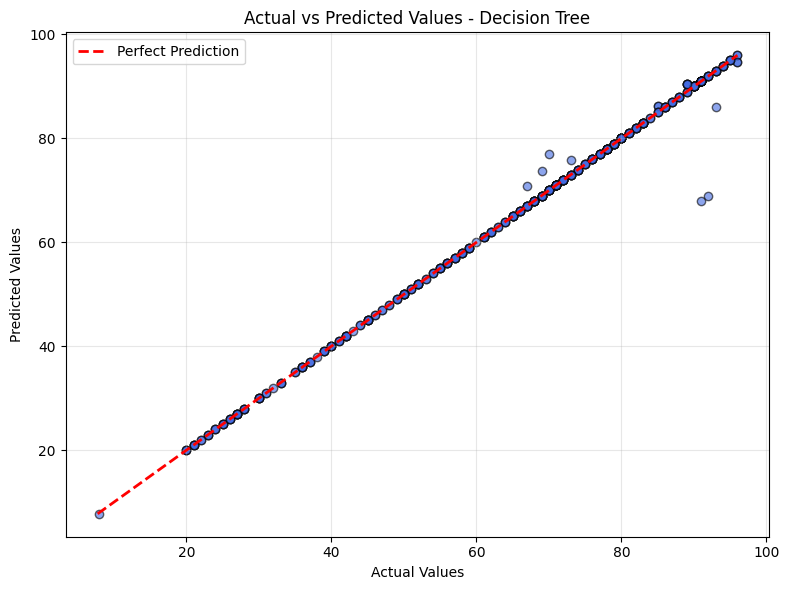

In [ ]:
# ------------------------------------------------------------
# 4. CALCULATE RESIDUALS / ERRORS
# ------------------------------------------------------------

residuals = y_actual - y_pred
absolute_errors = np.abs(residuals)
squared_errors = residuals ** 2


# ------------------------------------------------------------
# 5. ACTUAL VS PREDICTED
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_actual,
    y_pred,
    alpha=0.6,
    color="royalblue",
    edgecolor="black"
)

# Perfect prediction line
min_value = min(y_actual.min(), y_pred.min())
max_value = max(y_actual.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values - Decision Tree")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


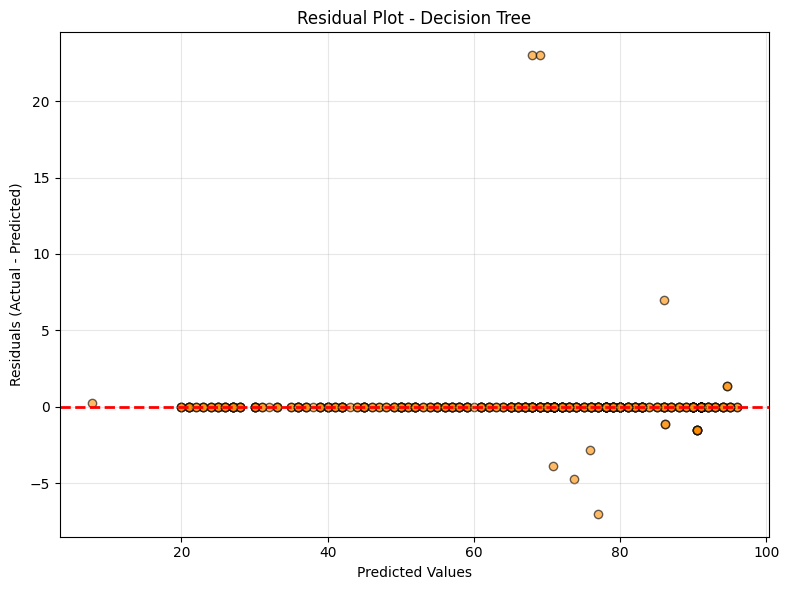

In [ ]:


# ------------------------------------------------------------
# 6. RESIDUAL PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6,
    color="darkorange",
    edgecolor="black"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Decision Tree")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



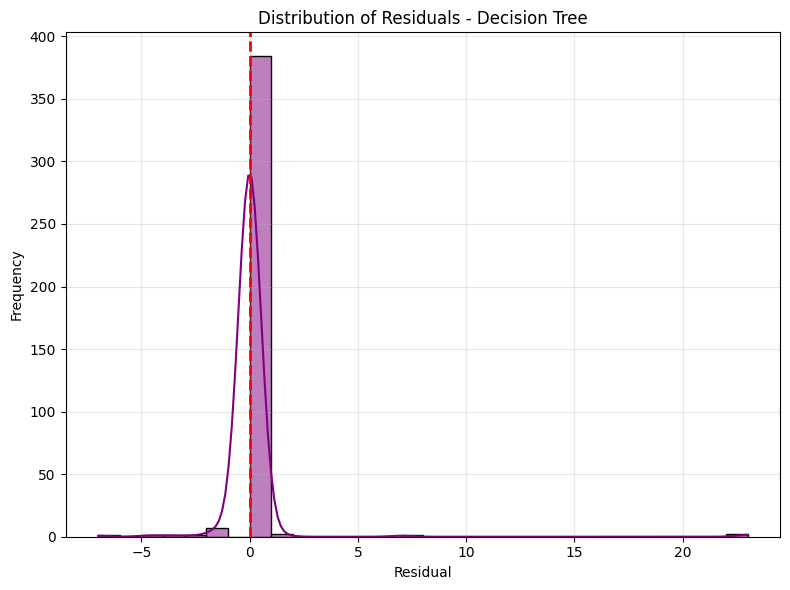

In [ ]:

# ------------------------------------------------------------
# 7. RESIDUAL DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color="purple"
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals - Decision Tree")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


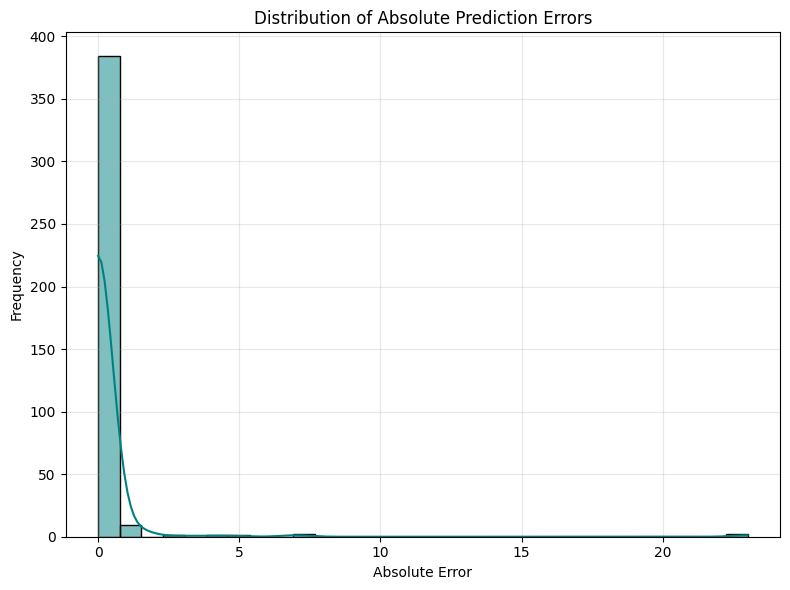

In [ ]:


# ------------------------------------------------------------
# 8. ABSOLUTE ERROR DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.histplot(
    absolute_errors,
    bins=30,
    kde=True,
    color="teal"
)

plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Distribution of Absolute Prediction Errors")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

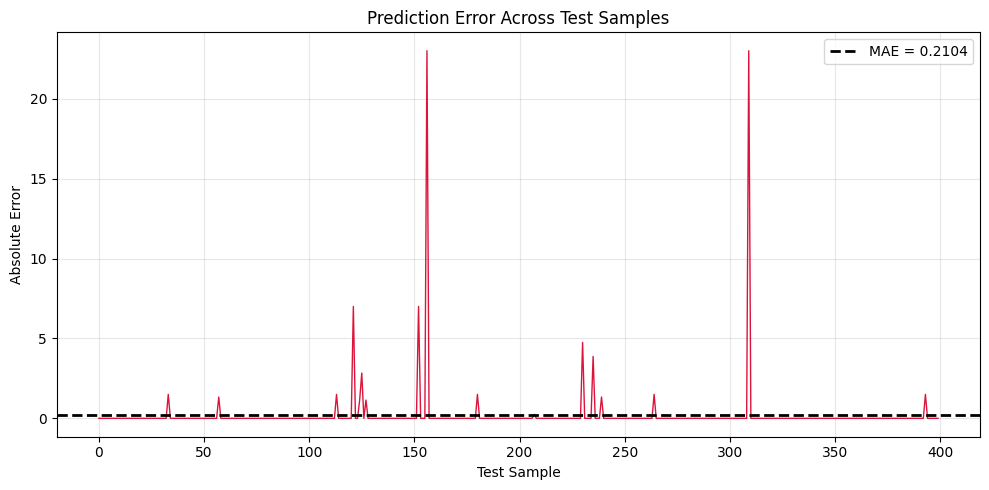

In [ ]:



# ------------------------------------------------------------
# 9. ERROR BY SAMPLE
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    absolute_errors,
    color="crimson",
    linewidth=1
)

plt.axhline(
    y=mae,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"MAE = {mae:.4f}"
)

plt.xlabel("Test Sample")
plt.ylabel("Absolute Error")
plt.title("Prediction Error Across Test Samples")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


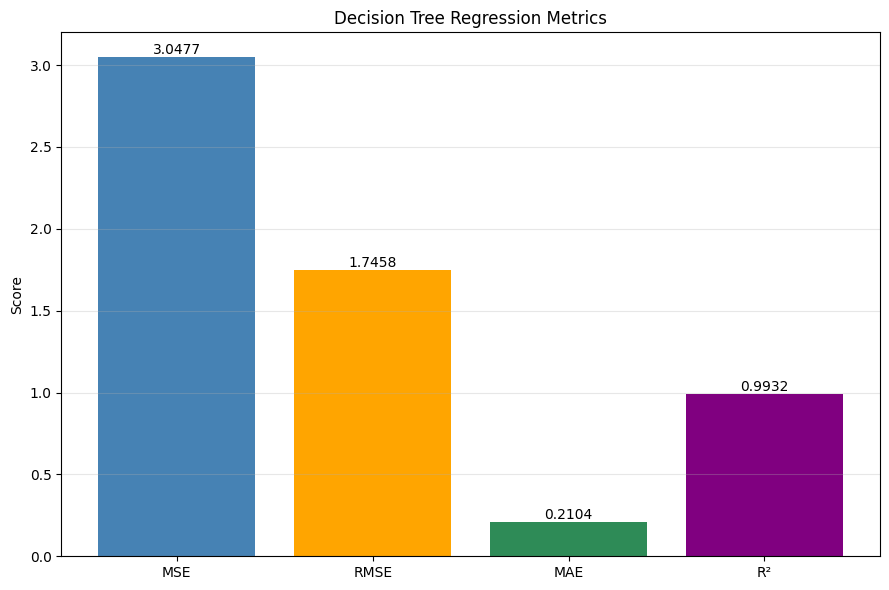

In [ ]:


# ------------------------------------------------------------
# 10. METRICS BAR CHART
# ------------------------------------------------------------

metric_names = [
    "MSE",
    "RMSE",
    "MAE",
    "R²"
]

metric_values = [
    mse,
    rmse,
    mae,
    r2
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    metric_names,
    metric_values,
    color=[
        "steelblue",
        "orange",
        "seagreen",
        "purple"
    ]
)

plt.ylabel("Score")
plt.title("Decision Tree Regression Metrics")

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:


# ------------------------------------------------------------
# 11. FEATURE IMPORTANCE
# ------------------------------------------------------------

# Get the trained Decision Tree from the pipeline
tree_model = best_model.named_steps["model"]

# Get transformed feature names
preprocessor_fitted = best_model.named_steps["preprocess"]

try:
    feature_names = preprocessor_fitted.get_feature_names_out()

    importances = tree_model.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    feature_importance_df = (
        feature_importance_df
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    print("\n" + "=" * 70)
    print("TOP 20 FEATURE IMPORTANCES")
    print("=" * 70)

    print(
        feature_importance_df.head(20).to_string(index=False)
    )

    # Plot top 20 features
    top_features = feature_importance_df.head(20).sort_values(
        "Importance",
        ascending=True
    )

    plt.figure(figsize=(10, 8))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"],
        color="steelblue"
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title("Top 20 Feature Importances - Decision Tree")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("\nFeature importance could not be extracted.")
    print("Reason:", e)

In [ ]:



# ------------------------------------------------------------
# 12. ACTUAL VS PREDICTED TABLE
# ------------------------------------------------------------

prediction_results = pd.DataFrame({
    "Actual": y_actual,
    "Predicted": y_pred,
    "Residual": residuals,
    "Absolute_Error": absolute_errors,
    "Squared_Error": squared_errors
})

print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)

print(prediction_results.head(20).to_string(index=False))



SAMPLE PREDICTIONS
 Actual  Predicted  Residual  Absolute_Error  Squared_Error
   51.0       51.0       0.0             0.0            0.0
   47.0       47.0       0.0             0.0            0.0
   69.0       69.0       0.0             0.0            0.0
   72.0       72.0       0.0             0.0            0.0
   69.0       69.0       0.0             0.0            0.0
   74.0       74.0       0.0             0.0            0.0
   72.0       72.0       0.0             0.0            0.0
   91.0       91.0       0.0             0.0            0.0
   42.0       42.0       0.0             0.0            0.0
   80.0       80.0       0.0             0.0            0.0
   25.0       25.0       0.0             0.0            0.0
   95.0       95.0       0.0             0.0            0.0
   86.0       86.0       0.0             0.0            0.0
   86.0       86.0       0.0             0.0            0.0
   66.0       66.0       0.0             0.0            0.0
   78.0       78.0  

In [ ]:


# ------------------------------------------------------------
# 13. BEST / WORST PREDICTIONS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BEST PREDICTIONS")
print("=" * 70)

print(
    prediction_results
    .sort_values("Absolute_Error")
    .head(10)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("WORST PREDICTIONS")
print("=" * 70)

print(
    prediction_results
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
    .to_string(index=False)
)


BEST PREDICTIONS
 Actual  Predicted  Residual  Absolute_Error  Squared_Error
   75.0       75.0       0.0             0.0            0.0
   68.0       68.0       0.0             0.0            0.0
   70.0       70.0       0.0             0.0            0.0
   26.0       26.0       0.0             0.0            0.0
   91.0       91.0       0.0             0.0            0.0
   45.0       45.0       0.0             0.0            0.0
   94.0       94.0       0.0             0.0            0.0
   20.0       20.0       0.0             0.0            0.0
   90.0       90.0       0.0             0.0            0.0
   39.0       39.0       0.0             0.0            0.0

WORST PREDICTIONS
 Actual  Predicted  Residual  Absolute_Error  Squared_Error
   91.0  68.000000 23.000000       23.000000     529.000000
   92.0  69.000000 23.000000       23.000000     529.000000
   70.0  77.000000 -7.000000        7.000000      49.000000
   93.0  86.000000  7.000000        7.000000      49.000000
   